<a href="https://colab.research.google.com/github/SWATHIRAVIRS/githubr/blob/main/email_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
data=pd.read_csv('email.csv')

In [3]:
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
data=data[['Category','Message']]
data.columns=['label','text']

In [5]:
print(data.head())
print(data['label'].value_counts())

  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64


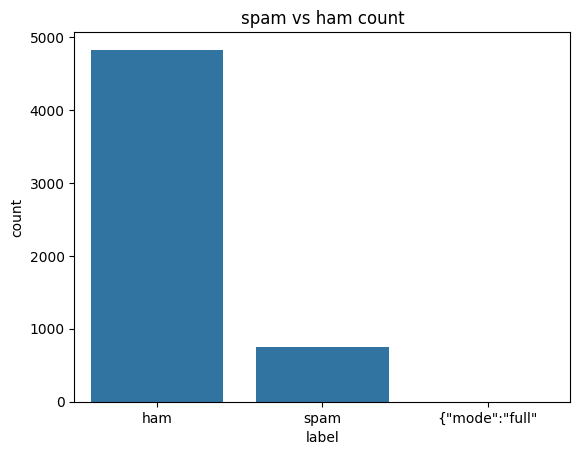

In [6]:
sns.countplot(x='label',data=data)
plt.title("spam vs ham count")
plt.show()

In [7]:
data['text_length']=data['text'].apply(len)
print(data[['text','text_length']].head())

                                                text  text_length
0  Go until jurong point, crazy.. Available only ...          111
1                      Ok lar... Joking wif u oni...           29
2  Free entry in 2 a wkly comp to win FA Cup fina...          155
3  U dun say so early hor... U c already then say...           49
4  Nah I don't think he goes to usf, he lives aro...           61


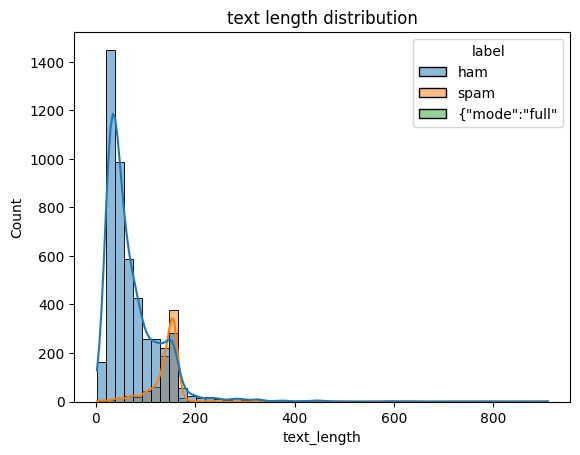

In [9]:
sns.histplot(data=data,x='text_length',hue='label',bins=50,kde=True)
plt.title("text length distribution")
plt.show()

In [10]:
data['labal']=data['label'].map({'ham':0,'spam':1})
print(data.head())

  label                                               text  text_length  labal
0   ham  Go until jurong point, crazy.. Available only ...          111    0.0
1   ham                      Ok lar... Joking wif u oni...           29    0.0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          155    1.0
3   ham  U dun say so early hor... U c already then say...           49    0.0
4   ham  Nah I don't think he goes to usf, he lives aro...           61    0.0


In [12]:
X=data['text']
y=data['label']

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
vectorizer=TfidfVectorizer(stop_words='english')
X_train_vectorized=vectorizer.fit_transform(X_train)
X_test_vectorized=vectorizer.transform(X_test)

In [21]:
model=LogisticRegression()
model.fit(X_train_vectorized,y_train)

LogisticRegression()

In [22]:
y_pred=model.predict(X_test_vectorized)

In [23]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9748878923766816


In [30]:
msg=["Congratulation!you won a free lottery.Click here"]
msg2=["hello you won a free car if you want it share it  with your 5 friends and send screenshot also pay 1000 initially"]
msg_vec=vectorizer.transform(msg)
prediction=model.predict(msg_vec)

if prediction[0]==0:
    print("ham")
else:
    print("spam")

spam
